# Tarea M54 - CD-YAIR PALOMARES

In [34]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings("ignore")

import os
os.chdir("C:/Users/yair_/OneDrive/Desktop/Ciencia de Datos/Módulo 54 - Modelos de regresión lineal y series de tiempo")

In [36]:
#Se lee la base de datos y se convierte en dataframe
ventas = pd.read_csv("Cientifico de datos M53 - Advertising.csv")
ventas

,TV,Radio,Newspaper,Sales
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,12.0
3,151.5,41.3,58.5,16.5
4,180.8,10.8,58.4,17.9
...,...,...,...,...
195,38.2,3.7,13.8,7.6
196,94.2,4.9,8.1,14.0
197,177.0,9.3,6.4,14.8
198,283.6,42.0,66.2,25.5


In [37]:
#Se agrega el intercepto
ventas.insert(0, 'Intercepto', 1)
ventas

,Intercepto,TV,Radio,Newspaper,Sales
0,1,230.1,37.8,69.2,22.1
1,1,44.5,39.3,45.1,10.4
2,1,17.2,45.9,69.3,12.0
3,1,151.5,41.3,58.5,16.5
4,1,180.8,10.8,58.4,17.9
...,...,...,...,...,...
195,1,38.2,3.7,13.8,7.6
196,1,94.2,4.9,8.1,14.0
197,1,177.0,9.3,6.4,14.8
198,1,283.6,42.0,66.2,25.5


In [38]:
#Definiendo las matrices
Xdata = ventas[["Intercepto", "TV", "Radio", "Newspaper"]].values
Ydata = ventas[["Sales"]].values

In [39]:
#Dividir en bases de entrenamiento y prueba
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(Xdata, Ydata, test_size = 0.3, random_state = 1)

x = x_train
y = y_train

In [40]:
#Opción de formato numérico para evitar que se coloquen decimales con notación científica
np.set_printoptions(formatter={"float_kind":"{:f}".format})

In [41]:
#Reporte automatizada de la regresión en python
import statsmodels.api as sm

regressor = sm.OLS(y, x). fit()
print(regressor.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.899
Model:                            OLS   Adj. R-squared:                  0.897
Method:                 Least Squares   F-statistic:                     405.2
Date:                Mon, 23 Mar 2026   Prob (F-statistic):           1.36e-67
Time:                        17:13:35   Log-Likelihood:                -272.35
No. Observations:                 140   AIC:                             552.7
Df Residuals:                     136   BIC:                             564.5
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          4.6614      0.368     12.650      0.0

In [42]:
#Definiendo las matrices nuevamente, eliminando la variable de Newspaper.
Xdata = ventas[["Intercepto", "TV", "Radio"]].values
Ydata = ventas[["Sales"]].values

In [43]:
#Dividir en bases de entrenamiento y prueba
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(Xdata, Ydata, test_size = 0.3, random_state = 1)

x = x_train
y = y_train

In [44]:
#Reporte automatizada de la regresión en python
import statsmodels.api as sm

regressor = sm.OLS(y, x). fit()
print(regressor.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.899
Model:                            OLS   Adj. R-squared:                  0.898
Method:                 Least Squares   F-statistic:                     612.0
Date:                Mon, 23 Mar 2026   Prob (F-statistic):           4.95e-69
Time:                        17:16:22   Log-Likelihood:                -272.37
No. Observations:                 140   AIC:                             550.7
Df Residuals:                     137   BIC:                             559.6
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          4.6390      0.350     13.240      0.0

In [46]:
#Modo manual de aplicar la regresión
XT_X = np.matmul(np.matrix.transpose(x), x)
XT_X_inv = np.linalg.inv(XT_X)
XT_Y = np.matmul(np.matrix.transpose(x), y)
betas = np.matmul(XT_X_inv, XT_Y)
betas

array([[4.639009],
       [0.055005],
       [0.101644]])

In [47]:
#Ventas pronosticadas cuando se invierte 100 en TV, 50 en Radio y 70 en Periódicos (Ojo que la publicidad en periódicos no está en la ecuación)

#valores para el pronóstico
f = np.array([[1], [100], [50]])

#Pronóstico puntual
Pron_puntual = float(np.matmul(np.matrix.transpose(f), betas))
Pron_puntual

15.22167566487722

In [51]:
#Cálculos para obtener el margen de error
import math
import scipy.stats

Y_pred = np.matmul(x, betas)
Resid = y - Y_pred
RSS = np.matmul(np.matrix.transpose(Resid), Resid)
s_cuad = RSS / (len(y) - x.shape[1])
s = math.sqrt(s_cuad)

#Grados de libertad: n - (k+1)
grados_libertad = len(y) - x.shape[1]
confianza = 0.90
q = (1 - confianza) / 2
t_critico = abs(scipy.stats.t.ppf(q, df=grados_libertad))

Margen_error = t_critico * (s * (float(np.matmul(np.matmul(np.matrix.transpose(f), XT_X_inv), f)) ** 0.5))
Margen_error

np.float64(0.5034711983440173)

In [52]:
#Límites del intervalo de confianza para el pronóstico puntual
Lim_inferior = Pron_puntual - Margen_error
Lim_superior = Pron_puntual + Margen_error
print("Intervalo de confianza: (", Lim_inferior, ",", Lim_superior, ")")

Intervalo de confianza: ( 14.718204466533201 , 15.725146863221237 )


# Validación de los supuestos del modelo

In [54]:
import scipy
#Cálculo de la asimetría en residuales
skew = float(scipy.stats.skew(Resid, bias=True))
print("La asimetría de los residuales es:", skew)
#Cálculo de la curtosis de residuales
kurtosis = float(scipy.stats.kurtosis(Resid, fisher=False))
print("La kurtosis de los residuales es:", kurtosis)
Jarque_Bera = (len(y)/6) * (skew**2 + (kurtosis-3)**2 / 4)
print("Valor del estadístico de Jarque Bera:", Jarque_Bera)
Nivel_confianza = 0.90
valor_chi2 = scipy.stats.chi2.ppf(Nivel_confianza, df = 2)
print("Valor crítico chi-cuadrada para la prueba de hipótesis", valor_chi2)

La asimetría de los residuales es: -0.5124182186793582
La kurtosis de los residuales es: 4.782590640126675
Valor del estadístico de Jarque Bera: 24.662861496031123
Valor crítico chi-cuadrada para la prueba de hipótesis 4.605170185988092


#### Conclusión: Dado que JB si es mayor al nivel crítico, se rechaza la hipótesis nula. Es decir, los residuales no se comportan bajo una distribución normal.
#### No se cumple el supuesto de normalidad.

In [56]:
from statsmodels.formula.api import ols
y_df = pd.DataFrame(y)
x_df = pd.DataFrame(x[:,1:3])
df = pd.concat([y_df, x_df.reindex(y_df.index)], axis = 1)
df.columns = ["Y", "X1", "X2"]
df

,Y,X1,X2
0,12.2,139.2,14.3
1,13.4,139.3,14.5
2,5.3,5.4,29.9
3,20.7,293.6,27.7
4,24.4,281.4,39.6
...,...,...,...
135,19.6,219.8,33.5
136,20.8,273.7,28.9
137,8.8,26.8,33.0
138,10.9,73.4,17.0


In [57]:
# Ajuste de regresión lineal múltiple
model = ols('Y ~ X1 + X2', data = df).fit()

from statsmodels.stats.stattools import durbin_watson

#Prueba de Durbin-Watson
durbin_watson(model.resid)

np.float64(2.0375161916374998)

#### Conclusión: Ddao que el valor de DW es cercano a 2, se concluye que no existe autocorrelación entre los residuales. Es decir, los errores son independientes entre sí.
#### Se cumple el supuesto de inexistencia de autocorrelación entre los residuales.

In [58]:
Resid_cuad = Resid ** 2
Resid_cuad = pd.DataFrame(Resid_cuad)

X1 = df.iloc[:,1]
X1_df = pd.DataFrame(X1)

X1cuad = X1 ** 2
X1cuad_df = pd.DataFrame(X1cuad)

X2 = df.iloc[:,2]
X2_df = pd.DataFrame(X2)

X2cuad = X2 ** 2
X2cuad_df = pd.DataFrame(X2cuad)

df_Aux = pd.concat([Resid_cuad, X1_df.reindex(y_df.index), X1cuad_df.reindex(y_df.index), X2_df.reindex(y_df.index), X2cuad_df.reindex(y_df.index)], axis=1)
df_Aux.columns = ['Residual', 'X1', 'X1cuad', 'X2', 'X2cuad']
df_Aux

,Residual,X1,X1cuad,X2,X2cuad
0,2.399962,139.2,19376.64,14.3,204.49
1,0.140633,139.3,19404.49,14.5,210.25
2,7.156605,5.4,29.16,29.9,894.01
3,8.432907,293.6,86200.96,27.7,767.29
4,0.066332,281.4,79185.96,39.6,1568.16
...,...,...,...,...,...
135,0.285292,219.8,48312.04,33.5,1122.25
136,3.353748,273.7,74911.69,28.9,835.21
137,0.445398,26.8,718.24,33.0,1089.00
138,0.245714,73.4,5387.56,17.0,289.00


In [60]:
#Ajuste de regresión lineal múltiple
modelAux = ols('Residual ~ X1 + X2 + X1cuad + X2cuad + (X1*X2)', data = df_Aux).fit()
RSqAux = modelAux.rsquared
Estadístico = len(y) * RSqAux
print("Valor estadístico:", Estadístico)
Nivel_confianza = 0.90
valor_chi2 = scipy.stats.chi2.ppf(Nivel_confianza, df = 5)
print("El valor estadístico chi-cuadrada es:", valor_chi2)

Valor estadístico: 11.353378151633503
El valor estadístico chi-cuadrada es: 9.236356899781123


#### Conclusión: Al superar el valor crítico de nuestro estadístico de prueba, hay evidencia suficiente de Heterocedasticidad, por lo que se puede considerar que hay desigualdad entre las varianzas de los residuales.
#### No se cumple el supuesto de Homocedasticidad

In [61]:
# Alternativa para la prueba de White
from statsmodels.stats.diagnostic import het_white

white_test = het_white(model.resid, model.model.exog)
print("Estadístico de prueba:", white_test[0])
print("Valor p:", white_test[1])

Estadístico de prueba: 11.353378151633706
Valor p: 0.04480664163871973


#### No se cumple el supuesto de Homocedasticidad

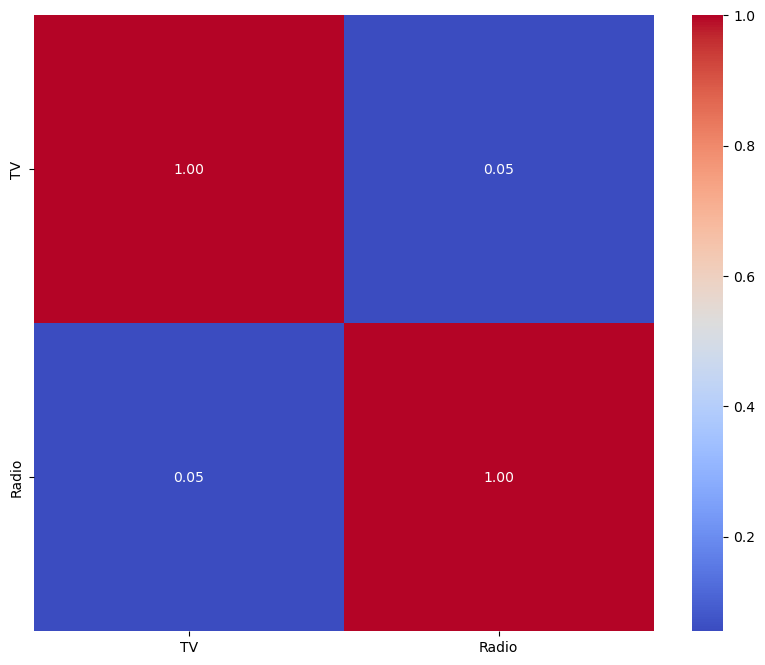

In [80]:
import seaborn as sns
import matplotlib.pyplot as plt

#Análisis de correlaciones entre las variables para identificar colinealidad
corr = ventas[["TV", "Radio"]].corr(numeric_only=True)

plt.figure(figsize=(10,8))
sns.heatmap(corr, cmap="coolwarm", annot=True, fmt=".2f")
plt.show()

Conclusión: Las dos variables independientes utilizadas en el modelo, no presentan multicolinealidas.

# Cálculo manual de Sesgo, Curtosis y Estadístico de Durbin Watson

In [75]:
#Cálculos para la asimetría
Mu_3 = ((Resid - Resid.mean())**3).sum() / len(Resid)
sigma_3 = (((Resid - Resid.mean())**2).sum() / len(Resid))**(3/2)
Sesgo = Mu_3/sigma_3
print(Sesgo)

-0.5124182186793583


In [76]:
#Cálculos para la curtosis
Mu_4 = ((Resid - Resid.mean())**4).sum() / len(Resid)
sigma_4 = (((Resid - Resid.mean())**2).sum() / len(Resid))**2
Curtosis = Mu_4/sigma_4
print(Curtosis)

4.782590640126675


In [78]:
#Cálculo del estadístico Durbin Watson
aux = 0
for i in range(1,len(Resid)):
    aux = aux + (Resid[i][0] - Resid[i-1][0])**2
Durbin = aux / (Resid**2).sum()
print(Durbin)

2.037516191637498
